# Lab_05_2_Heart_Disease_Classification

Heart Disease Classification(심장질환 이진분류)

## 목표

- 보유한 `heart.csv`를 불러와 앞부분 5행과 마지막 5행 확인하기
- 13개 원본 특성과 `target` 목표값 구분하기
- 숫자로 표시된 범주형 특성을 One-Hot Encoding(원핫 인코딩, 범주를 0과 1 열로 변환)하기
- 훈련 데이터와 테스트 데이터를 계층적으로 분할하기
- 훈련 데이터 통계량만 사용해 연속형 특성을 표준화하기
- `nn.Linear(입력 특성 수, 1)`과 `BCEWithLogitsLoss()`로 학습하기
- Accuracy(애큐러시, 정확도), Precision(프리시전, 정밀도), Recall(리콜, 재현율), F1 Score(에프원 스코어)를 계산하기
- Confusion Matrix(컨퓨전 매트릭스, 혼동행렬)와 분류 임계값의 의미 이해하기

**A probability is not yet a diagnosis; it becomes a class only after applying a threshold.**  
**확률은 아직 진단 결과가 아니며, 임계값을 적용한 뒤에 클래스가 됩니다.**


## 실습 흐름

```text
heart.csv 불러오기
→ 앞 5행·마지막 5행 확인
→ 입력 X와 목표 y 분리
→ 범주형 특성 원핫 인코딩
→ 훈련·테스트 분할
→ 훈련 데이터 기준 표준화
→ 로지스틱 회귀 학습
→ 확률과 클래스 예측
→ 혼동행렬·평가지표 해석
```

## 1. 준비

### 1.1 라이브러리 불러오기

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

# 같은 결과를 재현할 수 있도록 난수 고정
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("PyTorch 버전:", torch.__version__)
print("현재 작업 폴더:", Path.cwd())

PyTorch 버전: 2.13.0+cu130
현재 작업 폴더: /home/jung/Python_Project/PyTorch


## 2. 데이터

### 2.1 `heart.csv` 불러오기

- Colab(코랩): 현재 폴더에 파일이 없으면 업로드 창 표시
- 로컬 Jupyter Notebook(주피터 노트북): 노트북의 현재 작업 폴더에 `heart.csv` 배치
- `utf-8-sig`는 파일 첫 열에 포함될 수 있는 BOM(봄, 바이트 순서 표시)을 제거

In [2]:
data_path = Path("heart.csv")

# Colab에서 파일이 없으면 직접 업로드
if not data_path.exists():
    try:
        from google.colab import files

        uploaded_files = files.upload()
        if "heart.csv" not in uploaded_files:
            raise FileNotFoundError("heart.csv를 선택해 주세요.")
    except ImportError as error:
        raise FileNotFoundError(
            "현재 작업 폴더에 heart.csv를 넣은 뒤 다시 실행해 주세요."
        ) from error

heart_data = pd.read_csv(data_path, encoding="utf-8-sig")

print("데이터 파일:", data_path.resolve())
print("데이터 형상:", heart_data.shape)
print("열 이름:", heart_data.columns.tolist())

데이터 파일: /home/jung/Python_Project/PyTorch/heart.csv
데이터 형상: (303, 14)
열 이름: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


### 2.2 CSV 데이터 출력해 보기

학습 전에 파일이 올바르게 읽혔는지 먼저 확인합니다.

- 앞부분 5행
- 마지막 5행
- 전체 행과 열의 개수

데이터 구조를 확인한 뒤에는 아래의 두 출력문을 주석 처리해도 됩니다.

In [3]:
# CSV 데이터 확인용 출력
# 전체 흐름을 확인한 뒤에는 아래 2개 print 문을 주석 처리할 수 있음
print("CSV 앞부분 5행:")
print(heart_data.head(5))

print("\nCSV 마지막 5행:")
print(heart_data.tail(5))

print("\nCSV 형상:", heart_data.shape)

CSV 앞부분 5행:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

CSV 마지막 5행:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1     

### 2.3 열의 의미 확인하기

| 열 이름 | 의미 |
|---|---|
| `age` | 나이 |
| `sex` | 성별 코드 |
| `cp` | Chest Pain(체스트 페인, 흉통) 유형 |
| `trestbps` | 안정 시 혈압 |
| `chol` | 혈중 콜레스테롤 |
| `fbs` | Fasting Blood Sugar(패스팅 블러드 슈거, 공복 혈당) 기준 초과 여부 |
| `restecg` | 안정 시 심전도 결과 |
| `thalach` | 최대 심박수 |
| `exang` | 운동 유발 협심증 여부 |
| `oldpeak` | 운동 대비 안정 시 ST 분절 저하 |
| `slope` | 최대 운동 ST 분절 기울기 |
| `ca` | 형광투시로 확인한 주요 혈관 수 코드 |
| `thal` | Thalassemia(탈라세미아, 지중해빈혈 관련 검사) 코드 |
| `target` | `0`: 심장질환 없음, `1`: 심장질환 있음 |

숫자로 저장되어 있어도 `cp`, `restecg`, `slope`, `ca`, `thal`은 연속적인 측정량이 아니라 **범주 코드**입니다.

### 2.4 데이터 품질과 목표값 분포 확인하기

In [4]:
print("열별 자료형:")
print(heart_data.dtypes)

print("\n열별 결측값 수:")
print(heart_data.isna().sum())

print("\n중복 행 수:", heart_data.duplicated().sum())

print("\ntarget 클래스별 데이터 수:")
print(heart_data["target"].value_counts().sort_index())

assert heart_data.shape[1] == 14, "예상한 14개 열과 다릅니다."
assert heart_data.isna().sum().sum() == 0, "결측값이 있습니다."
assert set(heart_data["target"].unique()) == {0, 1}, "target은 0과 1이어야 합니다."


열별 자료형:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

열별 결측값 수:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

중복 행 수: 1

target 클래스별 데이터 수:
target
0    138
1    165
Name: count, dtype: int64


## 3. 실습 단계

### 3.1 입력 특성과 목표값 분리하기

- 입력 `X`: `target`을 제외한 13개 원본 특성
- 목표 `y`: 심장질환 여부 `target`
- `target`은 모델 입력에 포함하지 않음

In [5]:
target_column = "target"
feature_columns = [column for column in heart_data.columns if column != target_column]

X_original = heart_data[feature_columns].copy()
y = heart_data[target_column].to_numpy(dtype=np.float32)

print("원본 입력 형상:", X_original.shape)
print("목표 형상:", y.shape)
print("원본 입력 특성 수:", len(feature_columns))

원본 입력 형상: (303, 13)
목표 형상: (303,)
원본 입력 특성 수: 13


### 3.2 범주형 특성을 원핫 인코딩하기

예를 들어 `cp`의 0·1·2·3은 크기의 순서가 아니라 서로 다른 흉통 유형입니다.  
따라서 각 범주를 독립된 0/1 열로 바꿉니다.

- 연속형: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`
- 이진형: `sex`, `fbs`, `exang`
- 다범주형: `cp`, `restecg`, `slope`, `ca`, `thal`

**Category codes are labels, not measured quantities.**  
**범주 코드는 이름표이지 측정량이 아닙니다.**

In [6]:
continuous_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_columns = ["sex", "fbs", "exang"]
categorical_columns = ["cp", "restecg", "slope", "ca", "thal"]

# 다범주형 특성만 원핫 인코딩
X_encoded = pd.get_dummies(
    X_original,
    columns=categorical_columns,
    prefix=categorical_columns,
    dtype=np.float32,
)

# 모든 입력값을 float32로 통일
X_encoded = X_encoded.astype(np.float32)

print("원핫 인코딩 전 형상:", X_original.shape)
print("원핫 인코딩 후 형상:", X_encoded.shape)
print("\n변환된 입력 열:")
print(X_encoded.columns.tolist())

원핫 인코딩 전 형상: (303, 13)
원핫 인코딩 후 형상: (303, 27)

변환된 입력 열:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1', 'thal_2', 'thal_3']


### 3.3 훈련 데이터와 테스트 데이터 분할하기

각 클래스의 비율이 훈련·테스트 데이터에 비슷하게 유지되도록 Stratified Split(스트래티파이드 스플릿, 계층적 분할)을 NumPy(넘파이)로 구현합니다.

- 훈련 데이터: 약 80%
- 테스트 데이터: 약 20%
- 테스트 데이터는 학습에 사용하지 않음

In [7]:
def stratified_train_test_indices(labels, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_parts = []
    test_parts = []

    for class_value in np.unique(labels):
        class_indices = np.where(labels == class_value)[0]
        rng.shuffle(class_indices)

        test_count = int(round(len(class_indices) * test_ratio))
        test_parts.append(class_indices[:test_count])
        train_parts.append(class_indices[test_count:])

    train_indices = np.concatenate(train_parts)
    test_indices = np.concatenate(test_parts)

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    return train_indices, test_indices


train_indices, test_indices = stratified_train_test_indices(
    y,
    test_ratio=0.2,
    seed=RANDOM_SEED,
)

X_all = X_encoded.to_numpy(dtype=np.float32)
X_train = X_all[train_indices].copy()
X_test = X_all[test_indices].copy()
y_train = y[train_indices].reshape(-1, 1)
y_test = y[test_indices].reshape(-1, 1)

print("훈련 입력 형상:", X_train.shape)
print("테스트 입력 형상:", X_test.shape)
print("훈련 target=1 비율:", y_train.mean().round(4))
print("테스트 target=1 비율:", y_test.mean().round(4))

훈련 입력 형상: (242, 27)
테스트 입력 형상: (61, 27)
훈련 target=1 비율: 0.5455
테스트 target=1 비율: 0.541


### 3.4 훈련 데이터 기준으로 연속형 특성 표준화하기

표준화는 연속형 특성에만 적용합니다.

$$
x_{standardized}=\frac{x-\mu_{train}}{\sigma_{train}}
$$

- 평균과 표준편차는 **훈련 데이터에서만** 계산
- 테스트 데이터에는 훈련 데이터의 평균과 표준편차 적용
- 테스트 데이터의 통계량을 미리 사용하면 Data Leakage(데이터 리키지, 데이터 누출) 발생

In [8]:
encoded_column_names = X_encoded.columns.tolist()
continuous_indices = [
    encoded_column_names.index(column) for column in continuous_columns
]

# 훈련 데이터에서만 평균과 표준편차 계산
train_mean = X_train[:, continuous_indices].mean(axis=0, keepdims=True)
train_std = X_train[:, continuous_indices].std(axis=0, keepdims=True)
train_std = np.where(train_std == 0, 1.0, train_std)

X_train[:, continuous_indices] = (
    X_train[:, continuous_indices] - train_mean
) / train_std

X_test[:, continuous_indices] = (
    X_test[:, continuous_indices] - train_mean
) / train_std

print("표준화된 훈련 연속형 특성 평균:")
print(np.round(X_train[:, continuous_indices].mean(axis=0), 4))
print("\n표준화된 훈련 연속형 특성 표준편차:")
print(np.round(X_train[:, continuous_indices].std(axis=0), 4))

표준화된 훈련 연속형 특성 평균:
[ 0. -0.  0.  0.  0.]

표준화된 훈련 연속형 특성 표준편차:
[1. 1. 1. 1. 1.]


### 3.5 NumPy 배열을 PyTorch 텐서로 변환하기

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

input_size = X_train_tensor.shape[1]

print("모델 입력 특성 수:", input_size)
print("훈련 텐서 형상:", X_train_tensor.shape, y_train_tensor.shape)
print("테스트 텐서 형상:", X_test_tensor.shape, y_test_tensor.shape)

모델 입력 특성 수: 27
훈련 텐서 형상: torch.Size([242, 27]) torch.Size([242, 1])
테스트 텐서 형상: torch.Size([61, 27]) torch.Size([61, 1])


### 3.6 로지스틱 회귀 모델 정의하기

모델은 입력 특성으로 로짓 하나를 출력합니다.

$$
z=XW^T+b
$$

$$
P(y=1|X)=\sigma(z)
$$

- 모델 출력: Logit(로짓, 시그모이드 적용 전 점수)
- 손실함수: `BCEWithLogitsLoss()`
- 예측할 때만 `torch.sigmoid()` 적용

In [10]:
class HeartDiseaseLogisticModel(nn.Module):
    def __init__(self, number_of_features):
        super().__init__()
        self.linear = nn.Linear(number_of_features, 1)

    def forward(self, x):
        return self.linear(x)


model = HeartDiseaseLogisticModel(input_size)

# 학습 시작값을 일정하게 설정
nn.init.zeros_(model.linear.weight)
nn.init.zeros_(model.linear.bias)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

print(model)
print("가중치 형상:", model.linear.weight.shape)
print("편향 형상:", model.linear.bias.shape)

HeartDiseaseLogisticModel(
  (linear): Linear(in_features=27, out_features=1, bias=True)
)
가중치 형상: torch.Size([1, 27])
편향 형상: torch.Size([1])


### 3.7 모델 학습하기

학습 순서는 `로짓 계산 → 손실 계산 → 기울기 초기화 → 역전파 → 가중치 갱신`입니다.

Epoch  400 | Loss 0.318467
Epoch  800 | Loss 0.307214
Epoch 1200 | Loss 0.302457
Epoch 1600 | Loss 0.299800
Epoch 2000 | Loss 0.298155


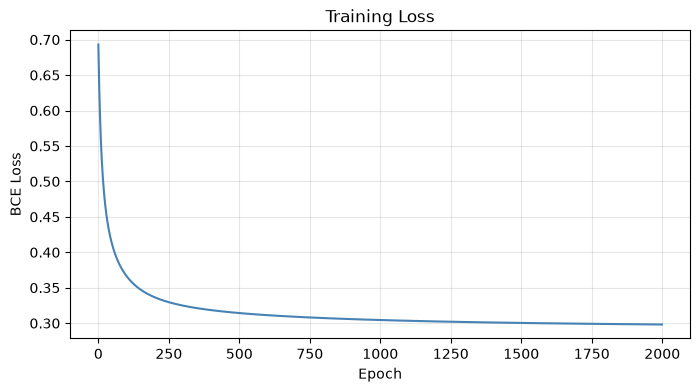

In [11]:
number_of_epochs = 2000
loss_history = []

for epoch in range(number_of_epochs):
    logits = model(X_train_tensor)
    loss = loss_function(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 400 == 0:
        print(f"Epoch {epoch + 1:4d} | Loss {loss.item():.6f}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.show()

## 4. 결과 확인

### 4.1 확률과 클래스 예측하기

- `sigmoid(logit)` → 심장질환 클래스 1일 확률
- 확률이 0.5 이상 → 예측 클래스 1
- 확률이 0.5 미만 → 예측 클래스 0

In [12]:
model.eval()

with torch.no_grad():
    train_logits = model(X_train_tensor)
    test_logits = model(X_test_tensor)

    train_probabilities = torch.sigmoid(train_logits)
    test_probabilities = torch.sigmoid(test_logits)

    train_predictions = (train_probabilities >= 0.5).float()
    test_predictions = (test_probabilities >= 0.5).float()

print("테스트 데이터 예측 예시 10개")
for actual, probability, prediction in zip(
    y_test_tensor[:10],
    test_probabilities[:10],
    test_predictions[:10],
):
    print(
        f"실제 {int(actual.item())} | "
        f"확률 {probability.item():.4f} | "
        f"예측 {int(prediction.item())}"
    )

테스트 데이터 예측 예시 10개
실제 0 | 확률 0.3221 | 예측 0
실제 1 | 확률 0.9949 | 예측 1
실제 0 | 확률 0.3230 | 예측 0
실제 1 | 확률 0.4339 | 예측 0
실제 0 | 확률 0.0013 | 예측 0
실제 0 | 확률 0.0431 | 예측 0
실제 1 | 확률 0.1750 | 예측 0
실제 1 | 확률 0.3521 | 예측 0
실제 1 | 확률 0.9458 | 예측 1
실제 1 | 확률 0.0082 | 예측 0


### 4.2 혼동행렬과 평가지표 계산하기

| 구분 | 의미 |
|---|---|
| TP | 실제 1을 1로 예측 |
| TN | 실제 0을 0으로 예측 |
| FP | 실제 0을 1로 예측 |
| FN | 실제 1을 0으로 예측 |

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
Precision=\frac{TP}{TP+FP}
$$

$$
Recall=\frac{TP}{TP+FN}
$$

$$
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
$$

의료 선별 문제에서는 실제 환자를 놓치는 FN(거짓 음성)을 줄이는 것이 중요하므로 Recall(재현율)을 함께 확인해야 합니다.

In [13]:
def calculate_binary_metrics(targets, predictions):
    targets = targets.reshape(-1).astype(int)
    predictions = predictions.reshape(-1).astype(int)

    true_positive = int(np.sum((targets == 1) & (predictions == 1)))
    true_negative = int(np.sum((targets == 0) & (predictions == 0)))
    false_positive = int(np.sum((targets == 0) & (predictions == 1)))
    false_negative = int(np.sum((targets == 1) & (predictions == 0)))

    accuracy = (true_positive + true_negative) / len(targets)
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1_score = (
        2 * precision * recall / max(precision + recall, 1e-12)
    )

    return {
        "TP": true_positive,
        "TN": true_negative,
        "FP": false_positive,
        "FN": false_negative,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1_score,
    }


train_metrics = calculate_binary_metrics(
    y_train,
    train_predictions.numpy(),
)
test_metrics = calculate_binary_metrics(
    y_test,
    test_predictions.numpy(),
)

print("훈련 데이터 평가")
for metric_name, metric_value in train_metrics.items():
    print(f"{metric_name:>9}: {metric_value:.4f}")

print("\n테스트 데이터 평가")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name:>9}: {metric_value:.4f}")

훈련 데이터 평가
       TP: 120.0000
       TN: 91.0000
       FP: 19.0000
       FN: 12.0000
 Accuracy: 0.8719
Precision: 0.8633
   Recall: 0.9091
       F1: 0.8856

테스트 데이터 평가
       TP: 27.0000
       TN: 27.0000
       FP: 1.0000
       FN: 6.0000
 Accuracy: 0.8852
Precision: 0.9643
   Recall: 0.8182
       F1: 0.8852


### 4.3 테스트 데이터 혼동행렬 시각화하기

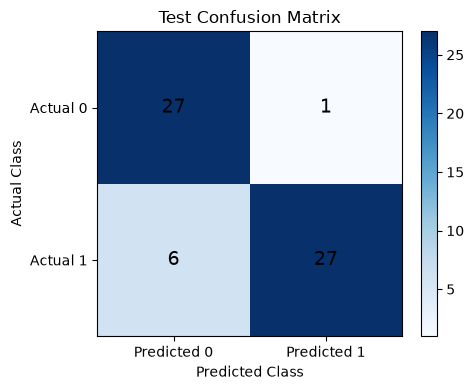

In [14]:
confusion_matrix = np.array(
    [
        [test_metrics["TN"], test_metrics["FP"]],
        [test_metrics["FN"], test_metrics["TP"]],
    ]
)

plt.figure(figsize=(5, 4))
plt.imshow(confusion_matrix, cmap="Blues")
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Test Confusion Matrix")

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusion_matrix[row, column],
            ha="center",
            va="center",
            fontsize=14,
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### 4.4 분류 임계값에 따른 결과 비교하기

임계값을 낮추면 클래스 1로 판단하는 경우가 늘어 Recall(재현율)이 높아질 수 있지만 FP(거짓 양성)도 증가할 수 있습니다.  
임계값은 정확도만 보고 정하지 않고 문제의 목적과 오판 비용을 함께 고려합니다.

In [15]:
test_probability_array = test_probabilities.numpy()

for threshold in [0.3, 0.5, 0.7]:
    threshold_predictions = (
        test_probability_array >= threshold
    ).astype(np.float32)
    threshold_metrics = calculate_binary_metrics(
        y_test,
        threshold_predictions,
    )

    print(
        f"임계값 {threshold:.1f} | "
        f"Accuracy {threshold_metrics['Accuracy']:.4f} | "
        f"Precision {threshold_metrics['Precision']:.4f} | "
        f"Recall {threshold_metrics['Recall']:.4f} | "
        f"F1 {threshold_metrics['F1']:.4f}"
    )

임계값 0.3 | Accuracy 0.8197 | Precision 0.8056 | Recall 0.8788 | F1 0.8406
임계값 0.5 | Accuracy 0.8852 | Precision 0.9643 | Recall 0.8182 | F1 0.8852
임계값 0.7 | Accuracy 0.7869 | Precision 0.9545 | Recall 0.6364 | F1 0.7636


### 4.5 훈련 결과와 테스트 결과 구분하기

- 훈련 성능: 모델이 학습에 사용한 데이터를 얼마나 잘 맞췄는지 확인
- 테스트 성능: 보지 않은 데이터에 얼마나 잘 일반화하는지 확인
- 훈련 성능만 높고 테스트 성능이 크게 낮으면 Overfitting(오버피팅, 과적합) 가능성
- 데이터가 303개로 작으므로 한 번의 분할 결과를 절대적인 의료 성능으로 해석하지 않음

## 5. 다음 단계

### 핵심 정리

- `heart.csv`는 303개 데이터, 13개 원본 입력 특성, 1개 이진 목표값으로 구성
- 숫자로 된 범주 코드는 원핫 인코딩으로 변환
- 연속형 특성은 훈련 데이터의 평균과 표준편차로 표준화
- 모델은 로짓을 출력하고 `BCEWithLogitsLoss()`로 학습
- 예측 단계에서 시그모이드로 확률을 계산하고 임계값으로 0/1 결정
- 이진분류 평가는 정확도 하나가 아니라 정밀도·재현율·F1·혼동행렬을 함께 확인

